In [1]:
!pip install google-play-scraper pandas nltk textblob matplotlib seaborn wordcloud

  Using cached google_play_scraper-1.2.7-py3-none-any.whl.metadata (50 kB)
  Using cached textblob-0.20.0-py3-none-any.whl.metadata (4.0 kB)
Using cached google_play_scraper-1.2.7-py3-none-any.whl (28 kB)
Using cached textblob-0.20.0-py3-none-any.whl (624 kB)

   ---------------------------------------- 0/2 [google-play-scraper]
   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [textblob]
   ---------------------------------------- 2/2 [textblob]



In [2]:
from google_play_scraper import reviews
import pandas as pd

result,_=reviews('com.instagram.android',
                lang='en',
                country='in',
                count=1000)

df=pd.DataFrame(result)
df=df[['content','score','at']]
df.columns=['review','rating','date']
print(df.head())

                                              review  rating  \
0       This app suspended my account for no reason.       1   
1  Not able to post after the update which took p...       1   
2                                               Good       5   
3  suspended my 2 accounts permanently of 5k and ...       1   
4  Instagram has been very fun and engaging 😄✨. I...       5   

                 date  
0 2026-05-02 13:54:17  
1 2026-05-02 13:52:11  
2 2026-05-02 13:51:23  
3 2026-05-02 13:50:36  
4 2026-05-02 13:50:17  


In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\S.B.
[nltk_data]     Engineering\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\S.B.
[nltk_data]     Engineering\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\S.B.
[nltk_data]     Engineering\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
from nltk.tokenize import word_tokenize

word_tokenize("This is a test sentence.")

['This', 'is', 'a', 'test', 'sentence', '.']

In [9]:
# import nltk
# import re
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize

# nltk.download('punkt')
# nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','', text)
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

In [11]:
from textblob import TextBlob

def sentiment_label(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['clean_review'].apply(sentiment_label)

print(df['sentiment'].value_counts())

sentiment
Positive    620
Neutral     266
Negative    114
Name: count, dtype: int64


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

negative_reviews = df[df['rating'] <= 2]['clean_review']

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(negative_reviews)

bigrams = vectorizer.get_feature_names_out()

print("Top complaint phrases:")
print(bigrams)

Top complaint phrases:
['account got' 'account reason' 'account suspended' 'account without'
 'community guidelines' 'dont know' 'followed community' 'got suspended'
 'id got' 'insta id' 'instagram account' 'instagram id' 'instagram team'
 'new account' 'please fix' 'please review' 'soon possible'
 'suspended account' 'team account' 'without reason']


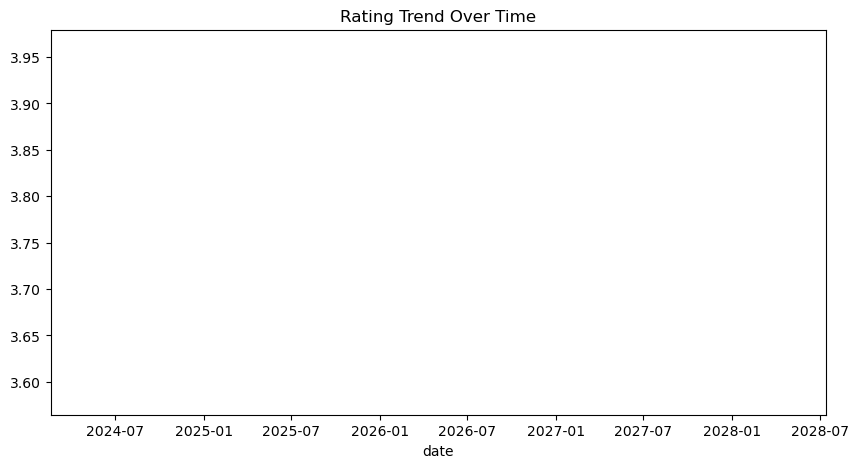

In [15]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

trend = df.groupby(df['date'].dt.date)['rating'].mean()

trend.plot(figsize=(10,5))
plt.title("Rating Trend Over Time")
plt.show()

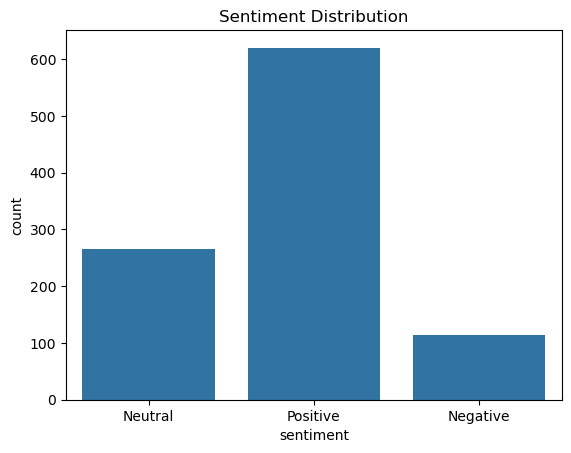

In [14]:
import seaborn as sns

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

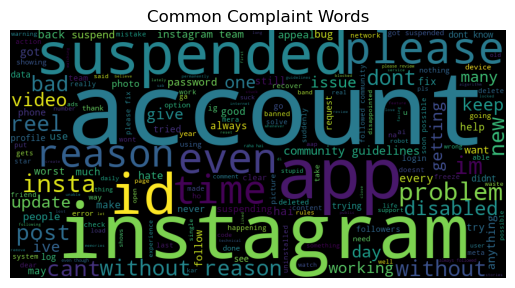

In [16]:
from wordcloud import WordCloud

negative_text = " ".join(negative_reviews)

wordcloud = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Common Complaint Words")
plt.show()

In [17]:
one_star_reviews = df[df['rating']==1]['clean_review']

vectorizer = CountVectorizer(max_features=15)
X = vectorizer.fit_transform(one_star_reviews)

print(vectorizer.get_feature_names_out())

['account' 'accounts' 'app' 'dont' 'even' 'got' 'id' 'im' 'insta'
 'instagram' 'please' 'reason' 'suspended' 'time' 'without']
